In [1]:
import LAMINAR

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.sparse import csr_matrix

import umap.umap_ as umap

h:\Uni\Master\Thesis\NFLAM\NFLAM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# generate 1000 random gaussian 2d samples
data = torch.randn(1000, 2)

# make a kd-tree from the data to get 15 closest points of the query point
tree = KDTree(data.numpy())
distances, neighs = tree.query(data.numpy(), k=15)

# make a graph with these connections
row_indices = torch.arange(neighs.shape[0]).repeat_interleave(neighs.shape[1])
col_indices = neighs.flatten()

graph = csr_matrix((distances.flatten().astype(np.float32), (row_indices, col_indices)), shape=(1000, 1000))
graph = graph.maximum(graph.transpose()).tocsc()

In [3]:
dist, path = LAMINAR.utils.dijkstra.dijkstra(graph, [i for i in range(1000)], [i for i in range(1000)])

In [4]:
dist = np.array(dist)

In [5]:
dist.shape

(1000, 1000)

In [6]:
dist

array([[0.        , 1.5505624 , 0.87839043, ..., 1.316426  , 1.0709659 ,
        0.39245164],
       [1.5505624 , 0.        , 2.191193  , ..., 2.6026523 , 0.5189725 ,
        1.2517267 ],
       [0.87839043, 2.191193  , 0.        , ..., 0.44076538, 1.6755286 ,
        0.97962505],
       ...,
       [1.316426  , 2.602652  , 0.44076538, ..., 0.        , 2.086988  ,
        1.3910843 ],
       [1.0709659 , 0.5189725 , 1.6755286 , ..., 2.086988  , 0.        ,
        0.75771636],
       [0.39245164, 1.2517267 , 0.9796251 , ..., 1.3910842 , 0.75771636,
        0.        ]], dtype=float32)

In [7]:
reducer = umap.UMAP(n_neighbors=2, min_dist=0.0, metric='precomputed', n_components=2)

h:\Uni\Master\Thesis\NFLAM\NFLAM\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


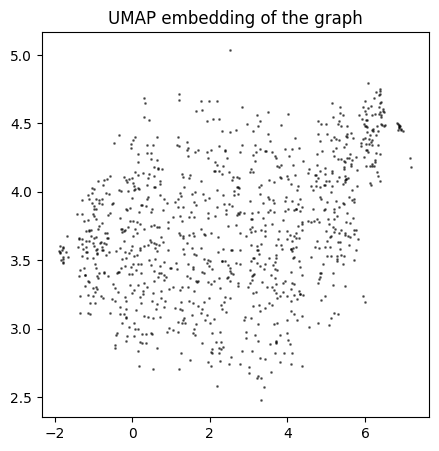

In [8]:
embed = reducer.fit_transform(graph.toarray())
plt.figure(figsize=(5, 5))
plt.scatter(embed[:, 0], embed[:, 1], s=1, c='black', alpha=0.5)
plt.title('UMAP embedding of the graph')
plt.show()